# Chương 2 – ML cơ bản
Nguyễn Minh Vinh · B23DCCN934. Code tự triển khai và kết quả thật. Chạy tuần tự từng cell; các cell train sẽ huấn luyện lại. So sánh scratch / Keras / PyTorch cùng cấu trúc, initialization, split và minibatch.

In [1]:
import os,sys,json
from pathlib import Path
os.environ['OPENBLAS_NUM_THREADS']='2'
os.environ['OMP_NUM_THREADS']='2'
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/experiment.py').exists())
sys.path.insert(0,str(ROOT/'src'))
from IPython.display import display,Image,Code


## 1. Scratch: forward, loss, backward và SGD
NumPy không dùng autograd. MLP áp dụng chain rule; CNN tính gradient kernel từ patch và phân phối gradient average pooling; RNN thực hiện BPTT từ bước cuối về đầu. Gradient clipping global norm=1 trước SGD.

In [2]:
"""NumPy forward/backward/SGD. No automatic differentiation in this module."""
import numpy as np

def initialize(kind,shape,outputs,seed=42):
    rng=np.random.default_rng(seed)
    def w(s,scale):return (rng.normal(size=s)*scale).astype(np.float32)
    if kind=='mlp':return {'w':w((shape[0],32),np.sqrt(2/shape[0])),'b':np.zeros(32,np.float32),'v':w((32,outputs),np.sqrt(1/32)),'c':np.zeros(outputs,np.float32)}
    if kind=='cnn':
        height,width,channels=shape;flat=((height-2)//2)*((width-2)//2)*8
        return {'w':w((3,3,channels,8),np.sqrt(2/(9*channels))),'b':np.zeros(8,np.float32),'v':w((flat,outputs),np.sqrt(1/flat)),'c':np.zeros(outputs,np.float32)}
    return {'w':w((shape[-1],16),np.sqrt(1/shape[-1])),'u':w((16,16),.15),'b':np.zeros(16,np.float32),'v':w((16,outputs),.2),'c':np.zeros(outputs,np.float32)}

def patches(x):
    return np.lib.stride_tricks.sliding_window_view(x,(3,3),axis=(1,2)).transpose(0,1,2,4,5,3)

def forward(p,x,kind,cache=False):
    if kind=='mlp':
        z=x@p['w']+p['b'];h=np.maximum(z,0);aux=(x,z,h)
    elif kind=='cnn':
        cols=patches(x);z=np.tensordot(cols,p['w'],axes=([3,4,5],[0,1,2]))+p['b']
        a=np.maximum(z,0);n,hh,ww,ch=a.shape
        h=a.reshape(n,hh//2,2,ww//2,2,ch).mean((2,4)).reshape(n,-1);aux=(cols,z,h)
    else:
        h=np.zeros((len(x),16),dtype=x.dtype);states=[h]
        for t in range(x.shape[1]):
            h=np.tanh(x[:,t]@p['w']+h@p['u']+p['b']);states.append(h)
        aux=(x,states,h)
    y=h@p['v']+p['c']
    return (y,aux) if cache else y

def objective(logits,y,task,weight=None):
    n=len(y)
    if task=='regression':
        delta=logits[:,0]-y
        return float(np.mean(delta**2)),(2*delta/n)[:,None]
    a=logits-logits.max(1,keepdims=True);exp=np.exp(a);prob=exp/exp.sum(1,keepdims=True)
    weights=np.ones(n) if weight is None else weight[y.astype(int)]
    loss=-(weights*(a[np.arange(n),y.astype(int)]-np.log(exp.sum(1)))).mean()
    grad=prob.copy();grad[np.arange(n),y.astype(int)]-=1;grad*=weights[:,None]/n
    return float(loss),grad

def backward(p,aux,dy,kind):
    x,z,h=aux;g={'v':h.T@dy,'c':dy.sum(0)};dh=dy@p['v'].T
    if kind=='mlp':
        dz=dh*(z>0);g.update(w=x.T@dz,b=dz.sum(0))
    elif kind=='cnn':
        n,hh,ww,ch=z.shape
        pooled=dh.reshape(n,hh//2,ww//2,ch)
        dz=np.repeat(np.repeat(pooled,2,axis=1),2,axis=2)/4*(z>0)
        g.update(w=np.tensordot(x,dz,axes=([0,1,2],[0,1,2])),b=dz.sum((0,1,2)))
    else:
        states=z;g.update(w=np.zeros_like(p['w']),u=np.zeros_like(p['u']),b=np.zeros_like(p['b']))
        for t in range(x.shape[1]-1,-1,-1):
            dz=dh*(1-states[t+1]**2)
            g['w']+=x[:,t].T@dz;g['u']+=states[t].T@dz;g['b']+=dz.sum(0)
            dh=dz@p['u'].T
    return g

def step(p,g,lr,clip=1.):
    norm=np.sqrt(sum(np.sum(v.astype(np.float64)**2) for v in g.values()))
    scale=min(1.,clip/(norm+1e-12))
    for k in p:p[k]-=lr*scale*g[k]

def probabilities(z):
    a=np.exp(z-z.max(1,keepdims=True));return a/a.sum(1,keepdims=True)


## 2. Hai framework cùng cấu trúc
PyTorch dùng ParameterDict và phép toán tensor tự động đạo hàm, đặc biệt RNN chỉ có một bias để trùng với scratch và Keras. Keras dùng Dense/Conv2D/SimpleRNN. Head giữ thứ tự flatten NHWC cho cả ba.

In [3]:
"""Matched architectures with one canonical recurrent bias in every implementation."""
import os
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL','2')
os.environ.setdefault('OMP_NUM_THREADS','2')
os.environ.setdefault('OPENBLAS_NUM_THREADS','2')
os.environ.setdefault('TF_NUM_INTRAOP_THREADS','2')
os.environ.setdefault('TF_NUM_INTEROP_THREADS','1')
import torch
from torch import nn
import tensorflow as tf
import numpy as np
torch.set_num_threads(2)

class TorchModel(nn.Module):
    def __init__(self,p,kind):
        super().__init__();self.kind=kind
        self.params=nn.ParameterDict({k:nn.Parameter(torch.tensor(v.copy())) for k,v in p.items()})
    def forward(self,x):
        p=self.params
        if self.kind=='mlp':h=torch.relu(x@p['w']+p['b'])
        elif self.kind=='cnn':
            a=nn.functional.conv2d(x.permute(0,3,1,2),p['w'].permute(3,2,0,1),p['b'])
            h=nn.functional.avg_pool2d(torch.relu(a),2).permute(0,2,3,1).reshape(len(x),-1)
        else:
            h=torch.zeros((len(x),16),dtype=x.dtype,device=x.device)
            for t in range(x.shape[1]):h=torch.tanh(x[:,t]@p['w']+h@p['u']+p['b'])
        return h@p['v']+p['c']

def keras_model(p,kind,shape):
    layers=tf.keras.layers
    inputs=layers.Input(shape=shape)
    if kind=='mlp':h=layers.Dense(32,activation='relu',name='hidden')(inputs)
    elif kind=='cnn':h=layers.Flatten()(layers.AveragePooling2D(2)(layers.Conv2D(8,3,activation='relu',name='hidden')(inputs)))
    else:h=layers.SimpleRNN(16,activation='tanh',name='hidden')(inputs)
    model=tf.keras.Model(inputs,layers.Dense(p['c'].size,name='head')(h))
    model.get_layer('hidden').set_weights([p['w'],p['u'],p['b']] if kind=='rnn' else [p['w'],p['b']])
    model.get_layer('head').set_weights([p['v'],p['c']]);return model

def export(model,framework,kind):
    if framework=='pytorch':return {k:v.detach().numpy().copy() for k,v in model.params.items()}
    values=model.get_layer('hidden').get_weights();p=dict(zip(['w','u','b'] if kind=='rnn' else ['w','b'],values));p['v'],p['c']=model.get_layer('head').get_weights();return p


## 3. Vòng train và metric
Cùng seed42, SGD không momentum, lr0,02 (MLP/RNN) hoặc0,04(CNN), batch128; epoch18 hoặc20. Chọn checkpoint validation loss nhỏ nhất. Chọn implementation bằng validation MacroF1 hoặc RMSE, rồi đọc test. Loss có class weights train, nhưng metric tính trên test tự nhiên.

In [4]:
from pathlib import Path
import json,time,copy,sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,average_precision_score,roc_auc_score,mean_squared_error,mean_absolute_error,r2_score,confusion_matrix
from sklearn.linear_model import LogisticRegression,Ridge
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
FRAMEWORKS=['scratch','keras','pytorch']
def load(key):
    z=np.load(ROOT/'data'/f'{key}.npz');d={k:z[k] for k in z.files};d['meta']=json.loads((ROOT/'results'/key/'summary.json').read_text(encoding='utf-8'));d['out']=ROOT/'results'/key;return d
def restore_target(d,indices,z):
    meta=d['meta'];v=z[:,0]*meta['y_std']+meta['y_mean']
    return d['last_close'][indices]*np.exp(v) if meta['key']=='stock' else np.expm1(v)
def metrics(d,ix,z):
    if d['meta']['task']=='regression':
        y=d['actual_close'][ix] if d['meta']['key']=='stock' else d['raw_y'][ix];p=restore_target(d,ix,z)
        return dict(RMSE=float(np.sqrt(mean_squared_error(y,p))),MAE=float(mean_absolute_error(y,p)),R2=float(r2_score(y,p)))
    y=d['y'][ix];prob=probabilities(z);pred=prob.argmax(1)
    m=dict(Accuracy=float(accuracy_score(y,pred)),MacroF1=float(f1_score(y,pred,average='macro',zero_division=0)))
    if prob.shape[1]==2:m.update(F1=float(f1_score(y,pred,zero_division=0)),Precision=float(precision_score(y,pred,zero_division=0)),Recall=float(recall_score(y,pred,zero_division=0)),AP=float(average_precision_score(y,prob[:,1])),ROC_AUC=float(roc_auc_score(y,prob[:,1])))
    return m
def predict(p,x,kind,batch=256):return np.concatenate([forward(p,x[i:i+batch],kind) for i in range(0,len(x),batch)])
def train(key,framework,seed=42):
    d=load(key);meta=d['meta'];kind=meta['kind'];task=meta['task'];x=d['x'];y=d['y'];tr,va=d['train'],d['val']
    outputs=len(meta['classes']) if task=='classification' else 1;p=initialize(kind,x.shape[1:],outputs,seed)
    epochs=20 if kind=='cnn' else 18;lr=.04 if kind=='cnn' else .02;batch=128
    weight=None
    if task=='classification':
        counts=np.bincount(y[tr].astype(int),minlength=outputs);weight=(len(tr)/(outputs*counts)).astype(np.float32)
    model=None
    if framework=='pytorch':
        model=TorchModel(p,kind);optimizer=torch.optim.SGD(model.parameters(),lr=lr)
        def update(xb,yb):
            optimizer.zero_grad();z=model(torch.tensor(xb))
            loss=((z[:,0]-torch.tensor(yb))**2).mean() if task=='regression' else (torch.nn.functional.cross_entropy(z,torch.tensor(yb,dtype=torch.long),reduction='none')*torch.tensor(weight)[torch.tensor(yb,dtype=torch.long)]).mean()
            loss.backward();torch.nn.utils.clip_grad_norm_(model.parameters(),1.);optimizer.step();return float(loss.detach())
    elif framework=='keras':
        model=keras_model(p,kind,x.shape[1:]);optimizer=tf.keras.optimizers.SGD(learning_rate=lr,global_clipnorm=1.)
        @tf.function(reduce_retracing=True)
        def update(xb,yb):
            with tf.GradientTape() as tape:
                z=model(xb,training=True)
                loss=tf.reduce_mean(tf.square(z[:,0]-yb)) if task=='regression' else tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(labels=tf.cast(yb,tf.int32),logits=z)*tf.gather(weight,tf.cast(yb,tf.int32)))
            optimizer.apply_gradients(zip(tape.gradient(loss,model.trainable_variables),model.trainable_variables));return loss
    else:
        def update(xb,yb):
            z,cache=forward(p,xb,kind,True);loss,dz=objective(z,yb,task,weight);g=backward(p,cache,dz,kind);step(p,g,lr);return loss
    best=np.inf;history=[];start=time.perf_counter()
    for epoch in range(1,epochs+1):
        order=np.random.default_rng(seed+epoch).permutation(tr);total=0
        for i in range(0,len(order),batch):
            ix=order[i:i+batch];total+=float(update(x[ix],y[ix]))*len(ix)
        if model is not None:p=export(model,framework,kind)
        val=objective(predict(p,x[va],kind),y[va],task,weight)[0]
        history.append(dict(epoch=epoch,train_loss=total/len(tr),val_loss=val))
        if val<best:best=val;bestp=copy.deepcopy(p);bestepoch=epoch
        print(key,framework,epoch,round(val,5),flush=True)
    seconds=time.perf_counter()-start;p=bestp;name=f'{framework}_{seed}';out=d['out'];np.savez_compressed(out/f'{name}.npz',**p)
    pd.DataFrame(history).to_csv(out/f'{name}_history.csv',index=False)
    validation=metrics(d,va,predict(p,x[va],kind));test=predict(p,x[d['test']],kind);np.savez_compressed(out/f'{name}_predictions.npz',logits=test,indices=d['test'])
    row=dict(framework=framework,seed=seed,epochs=epochs,best_epoch=bestepoch,lr=lr,batch=batch,parameters=sum(v.size for v in p.values()),seconds=seconds,validation=validation,test=metrics(d,d['test'],test))
    (out/f'{name}.json').write_text(json.dumps(row,indent=2))
    if framework=='pytorch':torch.save(TorchModel(p,kind).state_dict(),out/f'{name}.pth')
    elif framework=='keras':keras_model(p,kind,x.shape[1:]).save(out/f'{name}.keras')
    return row

def summarize(key):
    d=load(key);out=d['out'];meta=d['meta'];rows=[json.loads((out/f'{fw}_42.json').read_text()) for fw in FRAMEWORKS]
    criterion='RMSE' if meta['task']=='regression' else 'MacroF1'
    selected=sorted(rows,key=lambda r:r['validation'][criterion],reverse=meta['task']=='classification')[0]['framework']
    (out/'selection.json').write_text(json.dumps(dict(framework=selected,criterion=criterion,split='validation')))
    table=pd.DataFrame([dict(Framework=r['framework'],**r['test'],Parameters=r['parameters'],TrainSeconds=r['seconds'],BestEpoch=r['best_epoch']) for r in rows]);table.to_csv(out/'comparison.csv',index=False)
    fig,axes=plt.subplots(1,3,figsize=(12,3.2))
    for ax,fw in zip(axes,FRAMEWORKS):
        h=pd.read_csv(out/f'{fw}_42_history.csv');ax.plot(h.epoch,h.train_loss,label='train');ax.plot(h.epoch,h.val_loss,label='val');ax.set_title(fw);ax.legend()
    fig.tight_layout();fig.savefig(out/'learning.png',dpi=150);plt.close(fig)
    te=d['test'];z=np.load(out/f'{selected}_42_predictions.npz')['logits']
    fig,axes=plt.subplots(1,2,figsize=(10,3.5))
    if meta['task']=='classification':
        counts=np.bincount(d['y'].astype(int));axes[0].bar(np.arange(len(counts)),counts);axes[0].set_title('Benchmark label counts')
        cm=confusion_matrix(d['y'][te],z.argmax(1));axes[1].imshow(cm,cmap='Blues');axes[1].set_title(selected+' test confusion')
        for a in range(len(cm)):
            for b in range(len(cm)):axes[1].text(b,a,str(cm[a,b]),ha='center',va='center',fontsize=6)
        baseline_pred=np.full(len(te),np.bincount(d['y'][d['train']].astype(int)).argmax());base=dict(Accuracy=float(accuracy_score(d['y'][te],baseline_pred)),MacroF1=float(f1_score(d['y'][te],baseline_pred,average='macro',zero_division=0)))
        errors=np.flatnonzero(z.argmax(1)!=d['y'][te])[:8];examples=[dict(index=int(te[i]),actual=int(d['y'][te[i]]),prediction=int(z[i].argmax()),score=float(probabilities(z[i:i+1]).max())) for i in errors]
    else:
        actual=d['actual_close'][te] if key=='stock' else d['raw_y'][te];pred=restore_target(d,te,z)
        axes[0].hist(actual,bins=40);axes[0].set_title('Test target distribution')
        axes[1].scatter(actual,pred,s=5,alpha=.4);axes[1].plot([actual.min(),actual.max()],[actual.min(),actual.max()],'k--');axes[1].set(xlabel='Actual',ylabel='Prediction')
        b=d['last_close'][te] if key=='stock' else np.full(len(te),d['raw_y'][d['train']].mean());base=dict(RMSE=float(np.sqrt(mean_squared_error(actual,b))),MAE=float(mean_absolute_error(actual,b)),R2=float(r2_score(actual,b)))
        errors=np.argsort(abs(pred-actual))[-8:][::-1];examples=[dict(index=int(te[i]),actual=float(actual[i]),prediction=float(pred[i]),absolute_error=float(abs(pred[i]-actual[i]))) for i in errors]
    fig.tight_layout();fig.savefig(out/'evaluation.png',dpi=150);plt.close(fig)
    (out/'baseline.json').write_text(json.dumps(base,indent=2));(out/'errors.json').write_text(json.dumps(examples,indent=2))
    # Three observed input/output examples, not predictions invented for the report.
    examples=[]
    for ix in te[:3]:examples.append(dict(index=int(ix),input=np.round(d['x'][ix].reshape(-1)[:8],3).tolist(),target=float(d['raw_y'][ix])))
    (out/'samples.json').write_text(json.dumps(examples,indent=2))
    if meta['kind']=='cnn':
        fig,axes=plt.subplots(2,5,figsize=(10,4))
        for label,ax in enumerate(axes.flat):
            i=te[np.flatnonzero(d['y'][te]==label)[0]];ax.imshow(d['images'][i].squeeze(),cmap='gray' if key=='mnist' else None);ax.set_title(meta['classes'][label],fontsize=8);ax.axis('off')
        fig.tight_layout();fig.savefig(out/'samples.png',dpi=150);plt.close(fig)
    return table


## 4. Dataset diabetes
CDC BRFSS 2015: nhãn 0=no diabetes, 1=gộp prediabetes/diabetes. Gom nhóm predictor giống hệt trước chia tập để tránh leakage. Chỉ dùng benchmark 16.000/4.000/5.000 mẫu, không nhận là huấn luyện toàn bộ nguồn. Class weight tính từ train.

In [5]:
import subprocess
if not (ROOT/'data/diabetes.npz').exists():
    subprocess.run([sys.executable,str(ROOT/'tools/prepare.py'),'diabetes'],check=True)
data=load('diabetes')
display(pd.Series(data['meta']))
print('Input shape:',data['x'].shape)
display(pd.DataFrame(data['x'][data['train'][:3]].reshape(3,-1)[:,:8]))
print('Nhãn mẫu:',data['raw_y'][data['train'][:3]])

kind                                                       mlp
task                                            classification
classes                 [No diabetes, Prediabetes or diabetes]
raw_rows                                                253680
features     [HighBP, HighChol, CholCheck, BMI, Smoker, Str...
source       https://www.kaggle.com/datasets/alexteboul/dia...
protocol     Group by identical predictors; bounded stratif...
transform                                       train mean/std
mean         [0.45381250977516174, 0.43712499737739563, 0.9...
std          [0.4978955388069153, 0.4960578382015228, 0.190...
key                                                   diabetes
shape                                                     [21]
samples                                                  25000
splits             {'train': 16000, 'val': 4000, 'test': 5000}
counts       {'train': [13227, 2773], 'val': [3319, 681], '...
dtype: object

Input shape: (25000, 21)


,0,1,2,3,4,5,6,7
0,1.096992,1.134696,0.198399,0.181591,-0.934239,-0.215345,2.927572,-1.642404
1,1.096992,-0.881198,0.198399,-0.257189,-0.934239,-0.215345,-0.341632,0.608814
2,1.096992,1.134696,0.198399,-0.403449,-0.934239,-0.215345,-0.341632,0.608814


Nhãn mẫu: [0 0 0]


### Tiền xử lý cụ thể
Mã chuẩn bị dữ liệu được trình bày dưới đây để đối chiếu fit scope và nguồn. Khi cần tái tạo cache, chạy tools/prepare.py với tên dataset. Chuỗi thời gian có thêm prepare_sequences.py.

In [6]:
display(Code(filename=str(ROOT/'tools/prepare.py'),language='python'))

from pathlib import Path
import json,sys,io,zipfile,hashlib
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split,GroupShuffleSplit
ROOT=Path(__file__).resolve().parents[1]
DATA=ROOT/'data'
def save(key,x,y,split,meta,extras=None):
    out=ROOT/'results'/key;out.mkdir(parents=True,exist_ok=True)
    meta.update(key=key,shape=list(x.shape[1:]),samples=len(y),splits={k:len(v) for k,v in split.items()})
    if meta['task']=='classification':meta['counts']={k:np.bincount(y[v].astype(int),minlength=len(meta['classes'])).tolist() for k,v in split.items()}
    np.savez_compressed(DATA/f'{key}.npz',x=x.astype(np.float32),y=y,**split,**(extras or {}))
    (out/'summary.json').write_text(json.dumps(meta,ensure_ascii=False,indent=2),encoding='utf-8')
    print(key,meta['splits'],flush=True)

def split_random(y):
    ix=np.arange(len(y));tr,te=train_test_split(ix,test_size=.2,random_state=42,stratify=y)
    tr,va=train_test_split(tr,test_size=.2,random_state=42,stratify=y[tr]);return dict(train=tr,val=va,test=te)

def tabular(key):
    if key=='diabetes':
        df=pd.read_csv(DATA/'diabetes.csv');raw_count=len(df);df=df.drop_duplicates()
        target=(df.pop('Diabetes_012').to_numpy()>0).astype(np.int64)
        features=list(df);raw=df.to_numpy(np.float32);groups=pd.util.hash_pandas_object(df,index=False).to_numpy()
        tr,te=next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=42).split(raw,target,groups))
        a,b=next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=42).split(raw[tr],target[tr],groups[tr]));split=dict(train=tr[a],val=tr[b],test=te)
        # Subset each split by labels after grouping; no identical predictor crosses splits.
        for k,n in [('train',16000),('val',4000),('test',5000)]:
            ix=split[k]
            if len(ix)>n:split[k]=train_test_split(ix,train_size=n,random_state=42,stratify=target[ix])[0]
        chosen=np.concatenate(list(split.values()));mapping={int(v):i for i,v in enumerate(chosen)}
        split={k:np.array([mapping[int(v)] for v in ix]) for k,ix in split.items()};raw=raw[chosen];y=target[chosen]
        meta=dict(kind='mlp',task='classification',classes=['No diabetes','Prediabetes or diabetes'],raw_rows=raw_count,features=features,source='https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset',protocol='Group by identical predictors; bounded stratified subsets within splits',transform='train mean/std')
    else:
        df=pd.read_csv(DATA/'house_prices.csv');raw_count=len(df);df=df.drop_duplicates()
        df=df[(df.Area>0)&(df.Price>0)].copy()
        features=['Area','Frontage','Access Road','Floors','Bedrooms','Bathrooms']
        raw=df[features].to_numpy(np.float32);raw[raw<0]=np.nan
        groups=df.Address.fillna('Unknown').astype(str).to_numpy()
        tr,te=next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=42).split(df,groups=groups))
        a,b=next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=42).split(df.iloc[tr],groups=groups[tr]));split=dict(train=tr[a],val=tr[b],test=te)
        median=np.nanmedian(raw[split['train']],axis=0);raw=np.where(np.isnan(raw),median,raw);y=df.Price.to_numpy(np.float32)
        meta=dict(kind='mlp',task='regression',raw_rows=raw_count,features=features,median=median.tolist(),source='https://www.kaggle.com/datasets/nguyentiennhan/vietnam-housing-dataset-2024',protocol='Group split by exact Address, 64/16/20 approximate rows; no location feature',transform='log1p numeric, train mean/std',unit='billion VND')
        raw=np.log1p(raw)
    mean=raw[split['train']].mean(0);std=raw[split['train']].std(0);std[std<1e-6]=1
    meta.update(mean=mean.tolist(),std=std.tolist())
    if key=='housing':
        z=np.log1p(y);ym=z[split['train']].mean();ys=z[split['train']].std();meta.update(y_mean=float(ym),y_std=float(ys));extras={'raw_y':y};y=(z-ym)/ys
    else:extras={'raw_y':y}
    save(key,(raw-mean)/std,y,split,meta,extras)



### Huấn luyện scratch
Lưu history từng epoch, checkpoint tốt nhất, metric validation và dự đoán test. Không dùng trọng số hay số liệu từ bài mẫu.

In [7]:
row=train('diabetes','scratch')
display(row)

diabetes scratch 1 0.58756


diabetes scratch 2 0.56487


diabetes scratch 3 0.55622


diabetes scratch 4 0.55223


diabetes scratch 5 0.54901


...

diabetes scratch 15 0.53947


diabetes scratch 16 0.53874


diabetes scratch 17 0.53841


diabetes scratch 18 0.53809


{'framework': 'scratch',
 'seed': 42,
 'epochs': 18,
 'best_epoch': 18,
 'lr': 0.02,
 'batch': 128,
 'parameters': 770,
 'seconds': 0.4625328000402078,
 'validation': {'Accuracy': 0.6975,
  'MacroF1': 0.6252844431726825,
  'F1': 0.46078431372549017,
  'Precision': 0.3307741522712732,
  'Recall': 0.7591776798825257,
  'AP': 0.41866109374243465,
  'ROC_AUC': 0.7985067065916481},
 'test': {'Accuracy': 0.7056,
  'MacroF1': 0.6337981244493289,
  'F1': 0.47164393395549176,
  'Precision': 0.3427230046948357,
  'Recall': 0.7560414269275029,
  'AP': 0.44324143789869974,
  'ROC_AUC': 0.7966637222449252}}

### Huấn luyện keras
Lưu history từng epoch, checkpoint tốt nhất, metric validation và dự đoán test. Không dùng trọng số hay số liệu từ bài mẫu.

In [8]:
row=train('diabetes','keras')
display(row)

diabetes keras 1 0.58756


diabetes keras 2 0.56487


diabetes keras 3 0.55622


diabetes keras 4 0.55223


diabetes keras 5 0.54901


...

diabetes keras 15 0.53947


diabetes keras 16 0.53874


diabetes keras 17 0.53841


diabetes keras 18 0.53809


{'framework': 'keras',
 'seed': 42,
 'epochs': 18,
 'best_epoch': 18,
 'lr': 0.02,
 'batch': 128,
 'parameters': 770,
 'seconds': 2.2850814999546856,
 'validation': {'Accuracy': 0.6975,
  'MacroF1': 0.6252844431726825,
  'F1': 0.46078431372549017,
  'Precision': 0.3307741522712732,
  'Recall': 0.7591776798825257,
  'AP': 0.4186605055051721,
  'ROC_AUC': 0.798506485376104},
 'test': {'Accuracy': 0.7056,
  'MacroF1': 0.6337981244493289,
  'F1': 0.47164393395549176,
  'Precision': 0.3427230046948357,
  'Recall': 0.7560414269275029,
  'AP': 0.4432413814812849,
  'ROC_AUC': 0.7966635829629128}}

### Huấn luyện pytorch
Lưu history từng epoch, checkpoint tốt nhất, metric validation và dự đoán test. Không dùng trọng số hay số liệu từ bài mẫu.

In [9]:
row=train('diabetes','pytorch')
display(row)

diabetes pytorch 1 0.58756


diabetes pytorch 2 0.56487


diabetes pytorch 3 0.55622


diabetes pytorch 4 0.55223


diabetes pytorch 5 0.54901


...

diabetes pytorch 15 0.53947


diabetes pytorch 16 0.53874


diabetes pytorch 17 0.53841


diabetes pytorch 18 0.53809


{'framework': 'pytorch',
 'seed': 42,
 'epochs': 18,
 'best_epoch': 18,
 'lr': 0.02,
 'batch': 128,
 'parameters': 770,
 'seconds': 2.0877948999404907,
 'validation': {'Accuracy': 0.6975,
  'MacroF1': 0.6252844431726825,
  'F1': 0.46078431372549017,
  'Precision': 0.3307741522712732,
  'Recall': 0.7591776798825257,
  'AP': 0.4186625363109333,
  'ROC_AUC': 0.7985064853761041},
 'test': {'Accuracy': 0.7056,
  'MacroF1': 0.6337981244493289,
  'F1': 0.47164393395549176,
  'Precision': 0.3427230046948357,
  'Recall': 0.7560414269275029,
  'AP': 0.44324138148128495,
  'ROC_AUC': 0.7966634436809005}}

### So sánh và phân tích
Đọc số liệu và hình do các lần train vừa tạo. Metric giữa các framework gần nhau là điều có thể xảy ra khi cùng khởi tạo và cùng SGD; không tự suy ra framework nào tốt hơn từ một seed.

,Framework,Accuracy,MacroF1,F1,Precision,Recall,AP,ROC_AUC,Parameters,TrainSeconds,BestEpoch
0,scratch,0.7056,0.6338,0.47164,0.34272,0.75604,0.44324,0.79666,770,0.46253,18
1,keras,0.7056,0.6338,0.47164,0.34272,0.75604,0.44324,0.79666,770,2.28508,18
2,pytorch,0.7056,0.6338,0.47164,0.34272,0.75604,0.44324,0.79666,770,2.08779,18


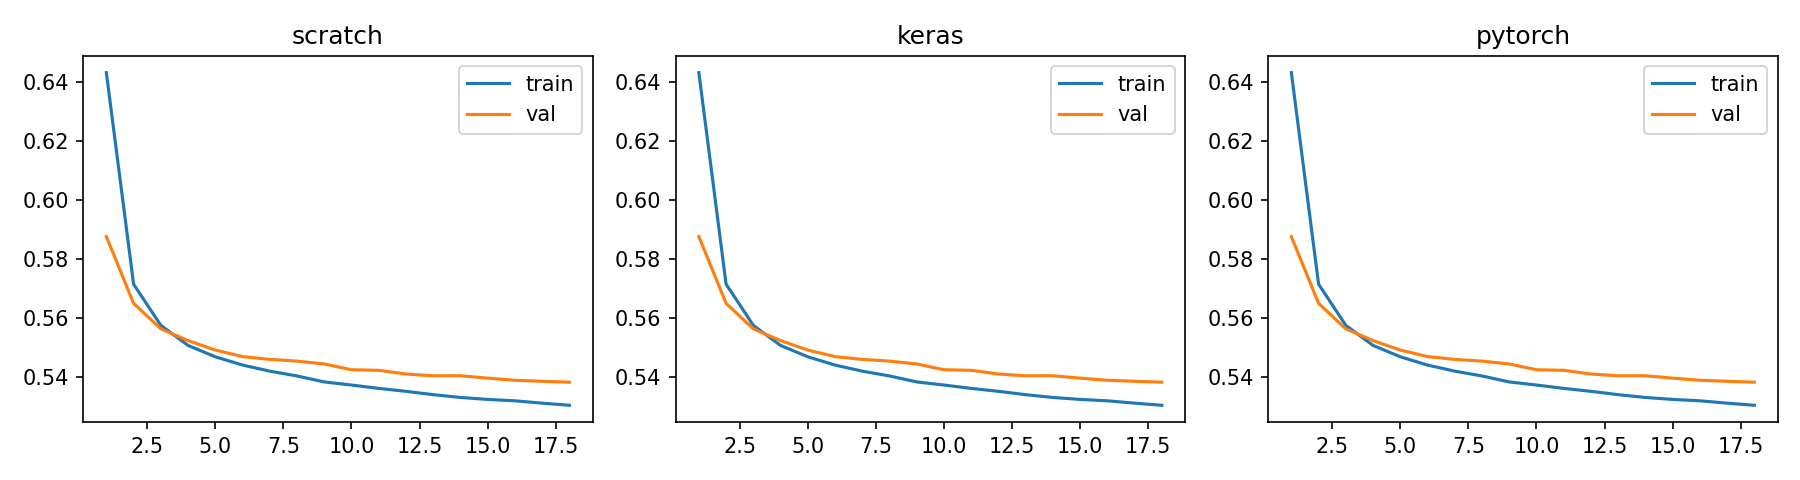

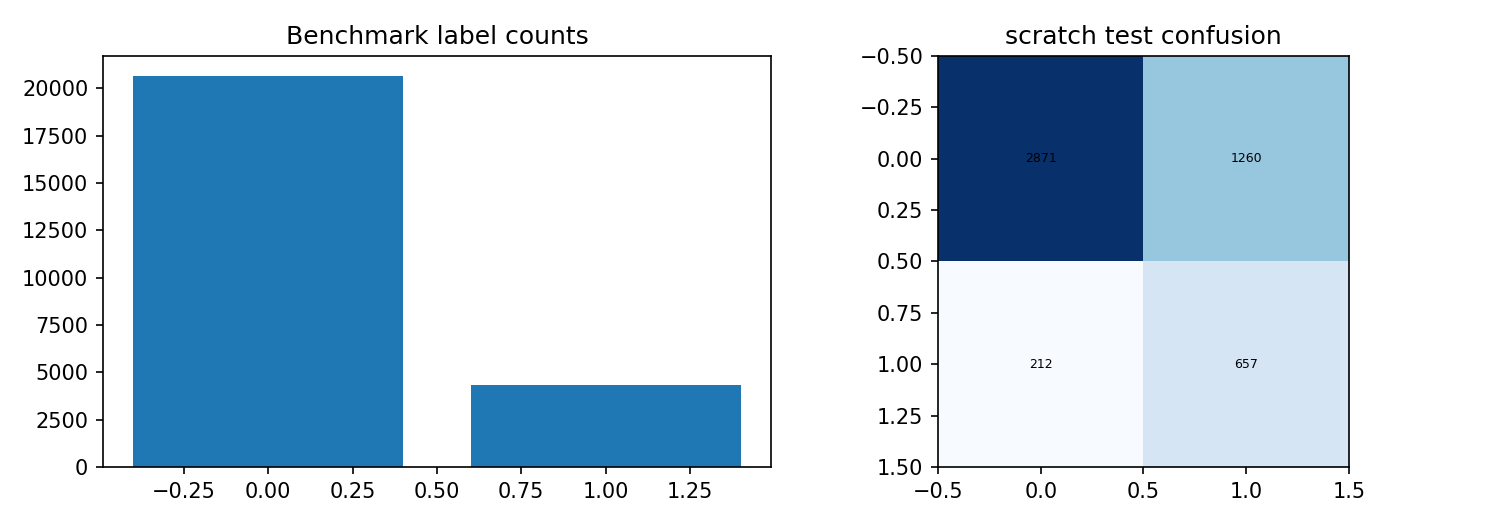

Baseline: {
  "Accuracy": 0.8262,
  "MacroF1": 0.4524148505092542
}
Chọn validation: {"framework": "scratch", "criterion": "MacroF1", "split": "validation"}


,index,actual,prediction,score
0,20000,0,1,0.679435
1,20003,0,1,0.684350
2,20004,0,1,0.590120
3,20005,0,1,0.641673
4,20007,0,1,0.752275
5,20013,1,0,0.507552
6,20014,0,1,0.573460
7,20016,0,1,0.703626


In [10]:
display(summarize('diabetes').round(5))
for file in ['learning.png','evaluation.png','samples.png']:
    path=ROOT/'results/diabetes'/file
    if path.exists():display(Image(filename=str(path)))
print('Baseline:',(ROOT/'results/diabetes/baseline.json').read_text())
print('Chọn validation:',(ROOT/'results/diabetes/selection.json').read_text())
display(pd.read_json(ROOT/'results/diabetes/errors.json'))

## 4. Dataset housing
Giá nhà Việt Nam 2024: sáu biến số diện tích/mặt tiền/đường/số tầng/phòng; chưa dùng vị trí. Chia theo Address để tránh cùng địa chỉ ở nhiều tập. Điền median train, log1p, chuẩn hóa train; target log1p(Price), đổi lại tỷ VND khi đánh giá. Không xóa ngoại lệ bằng phân vị test.

In [11]:
import subprocess
if not (ROOT/'data/housing.npz').exists():
    subprocess.run([sys.executable,str(ROOT/'tools/prepare.py'),'housing'],check=True)
data=load('housing')
display(pd.Series(data['meta']))
print('Input shape:',data['x'].shape)
display(pd.DataFrame(data['x'][data['train'][:3]].reshape(3,-1)[:,:8]))
print('Nhãn mẫu:',data['raw_y'][data['train'][:3]])

kind                                                       mlp
task                                                regression
raw_rows                                                 30229
features     [Area, Frontage, Access Road, Floors, Bedrooms...
median                         [56.0, 4.5, 6.0, 3.0, 3.0, 3.0]
source       https://www.kaggle.com/datasets/nguyentiennhan...
protocol     Group split by exact Address, 64/16/20 approxi...
transform                        log1p numeric, train mean/std
unit                                               billion VND
mean         [4.088815212249756, 1.7456917762756348, 1.9657...
std          [0.5021942853927612, 0.2529580593109131, 0.436...
y_mean                                                1.872678
y_std                                                 0.358694
key                                                    housing
shape                                                      [6]
samples                                                

Input shape: (30229, 6)


,0,1,2,3,4,5
0,0.704580,-0.161860,-0.045387,0.578088,-0.263657,-0.086728
1,0.043924,-0.161860,-0.045387,1.168423,-0.263657,-0.086728
2,0.840400,0.791508,1.543567,1.168423,-0.263657,-0.086728


Nhãn mẫu: [8.6 7.5 8.9]


### Tiền xử lý cụ thể
Mã chuẩn bị dữ liệu được trình bày dưới đây để đối chiếu fit scope và nguồn. Khi cần tái tạo cache, chạy tools/prepare.py với tên dataset. Chuỗi thời gian có thêm prepare_sequences.py.

In [12]:
display(Code(filename=str(ROOT/'tools/prepare.py'),language='python'))

from pathlib import Path
import json,sys,io,zipfile,hashlib
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split,GroupShuffleSplit
ROOT=Path(__file__).resolve().parents[1]
DATA=ROOT/'data'
def save(key,x,y,split,meta,extras=None):
    out=ROOT/'results'/key;out.mkdir(parents=True,exist_ok=True)
    meta.update(key=key,shape=list(x.shape[1:]),samples=len(y),splits={k:len(v) for k,v in split.items()})
    if meta['task']=='classification':meta['counts']={k:np.bincount(y[v].astype(int),minlength=len(meta['classes'])).tolist() for k,v in split.items()}
    np.savez_compressed(DATA/f'{key}.npz',x=x.astype(np.float32),y=y,**split,**(extras or {}))
    (out/'summary.json').write_text(json.dumps(meta,ensure_ascii=False,indent=2),encoding='utf-8')
    print(key,meta['splits'],flush=True)

def split_random(y):
    ix=np.arange(len(y));tr,te=train_test_split(ix,test_size=.2,random_state=42,stratify=y)
    tr,va=train_test_split(tr,test_size=.2,random_state=42,stratify=y[tr]);return dict(train=tr,val=va,test=te)

def tabular(key):
    if key=='diabetes':
        df=pd.read_csv(DATA/'diabetes.csv');raw_count=len(df);df=df.drop_duplicates()
        target=(df.pop('Diabetes_012').to_numpy()>0).astype(np.int64)
        features=list(df);raw=df.to_numpy(np.float32);groups=pd.util.hash_pandas_object(df,index=False).to_numpy()
        tr,te=next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=42).split(raw,target,groups))
        a,b=next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=42).split(raw[tr],target[tr],groups[tr]));split=dict(train=tr[a],val=tr[b],test=te)
        # Subset each split by labels after grouping; no identical predictor crosses splits.
        for k,n in [('train',16000),('val',4000),('test',5000)]:
            ix=split[k]
            if len(ix)>n:split[k]=train_test_split(ix,train_size=n,random_state=42,stratify=target[ix])[0]
        chosen=np.concatenate(list(split.values()));mapping={int(v):i for i,v in enumerate(chosen)}
        split={k:np.array([mapping[int(v)] for v in ix]) for k,ix in split.items()};raw=raw[chosen];y=target[chosen]
        meta=dict(kind='mlp',task='classification',classes=['No diabetes','Prediabetes or diabetes'],raw_rows=raw_count,features=features,source='https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset',protocol='Group by identical predictors; bounded stratified subsets within splits',transform='train mean/std')
    else:
        df=pd.read_csv(DATA/'house_prices.csv');raw_count=len(df);df=df.drop_duplicates()
        df=df[(df.Area>0)&(df.Price>0)].copy()
        features=['Area','Frontage','Access Road','Floors','Bedrooms','Bathrooms']
        raw=df[features].to_numpy(np.float32);raw[raw<0]=np.nan
        groups=df.Address.fillna('Unknown').astype(str).to_numpy()
        tr,te=next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=42).split(df,groups=groups))
        a,b=next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=42).split(df.iloc[tr],groups=groups[tr]));split=dict(train=tr[a],val=tr[b],test=te)
        median=np.nanmedian(raw[split['train']],axis=0);raw=np.where(np.isnan(raw),median,raw);y=df.Price.to_numpy(np.float32)
        meta=dict(kind='mlp',task='regression',raw_rows=raw_count,features=features,median=median.tolist(),source='https://www.kaggle.com/datasets/nguyentiennhan/vietnam-housing-dataset-2024',protocol='Group split by exact Address, 64/16/20 approximate rows; no location feature',transform='log1p numeric, train mean/std',unit='billion VND')
        raw=np.log1p(raw)
    mean=raw[split['train']].mean(0);std=raw[split['train']].std(0);std[std<1e-6]=1
    meta.update(mean=mean.tolist(),std=std.tolist())
    if key=='housing':
        z=np.log1p(y);ym=z[split['train']].mean();ys=z[split['train']].std();meta.update(y_mean=float(ym),y_std=float(ys));extras={'raw_y':y};y=(z-ym)/ys
    else:extras={'raw_y':y}
    save(key,(raw-mean)/std,y,split,meta,extras)



### Huấn luyện scratch
Lưu history từng epoch, checkpoint tốt nhất, metric validation và dự đoán test. Không dùng trọng số hay số liệu từ bài mẫu.

In [13]:
row=train('housing','scratch')
display(row)

housing scratch 1 0.79747


housing scratch 2 0.76891


housing scratch 3 0.75858


housing scratch 4 0.77785


housing scratch 5 0.75522


...

housing scratch 15 0.74711


housing scratch 16 0.73861


housing scratch 17 0.74201


housing scratch 18 0.74618


{'framework': 'scratch',
 'seed': 42,
 'epochs': 18,
 'best_epoch': 16,
 'lr': 0.02,
 'batch': 128,
 'parameters': 257,
 'seconds': 0.500105999992229,
 'validation': {'RMSE': 1.9149756919573035,
  'MAE': 1.5461839437484741,
  'R2': 0.27912139892578125},
 'test': {'RMSE': 1.875956037290924,
  'MAE': 1.4980127811431885,
  'R2': 0.27991431951522827}}

### Huấn luyện keras
Lưu history từng epoch, checkpoint tốt nhất, metric validation và dự đoán test. Không dùng trọng số hay số liệu từ bài mẫu.

In [14]:
row=train('housing','keras')
display(row)

housing keras 1 0.79747


housing keras 2 0.76891


housing keras 3 0.75858


housing keras 4 0.77785


housing keras 5 0.75522


...

housing keras 15 0.74711


housing keras 16 0.73861


housing keras 17 0.74201


housing keras 18 0.74618


{'framework': 'keras',
 'seed': 42,
 'epochs': 18,
 'best_epoch': 16,
 'lr': 0.02,
 'batch': 128,
 'parameters': 257,
 'seconds': 2.2980460999533534,
 'validation': {'RMSE': 1.9149754429529997,
  'MAE': 1.5461839437484741,
  'R2': 0.2791215777397156},
 'test': {'RMSE': 1.8759561008368095,
  'MAE': 1.4980130195617676,
  'R2': 0.2799142599105835}}

### Huấn luyện pytorch
Lưu history từng epoch, checkpoint tốt nhất, metric validation và dự đoán test. Không dùng trọng số hay số liệu từ bài mẫu.

In [15]:
row=train('housing','pytorch')
display(row)

housing pytorch 1 0.79747


housing pytorch 2 0.76891


housing pytorch 3 0.75858


housing pytorch 4 0.77785


housing pytorch 5 0.75522


...

housing pytorch 15 0.74711


housing pytorch 16 0.73861


housing pytorch 17 0.74201


housing pytorch 18 0.74618


{'framework': 'pytorch',
 'seed': 42,
 'epochs': 18,
 'best_epoch': 16,
 'lr': 0.02,
 'batch': 128,
 'parameters': 257,
 'seconds': 2.6011076999129727,
 'validation': {'RMSE': 1.9149754429529997,
  'MAE': 1.5461839437484741,
  'R2': 0.2791215777397156},
 'test': {'RMSE': 1.8759561008368095,
  'MAE': 1.4980130195617676,
  'R2': 0.2799142599105835}}

### So sánh và phân tích
Đọc số liệu và hình do các lần train vừa tạo. Metric giữa các framework gần nhau là điều có thể xảy ra khi cùng khởi tạo và cùng SGD; không tự suy ra framework nào tốt hơn từ một seed.

,Framework,RMSE,MAE,R2,Parameters,TrainSeconds,BestEpoch
0,scratch,1.87596,1.49801,0.27991,257,0.50011,16
1,keras,1.87596,1.49801,0.27991,257,2.29805,16
2,pytorch,1.87596,1.49801,0.27991,257,2.60111,16


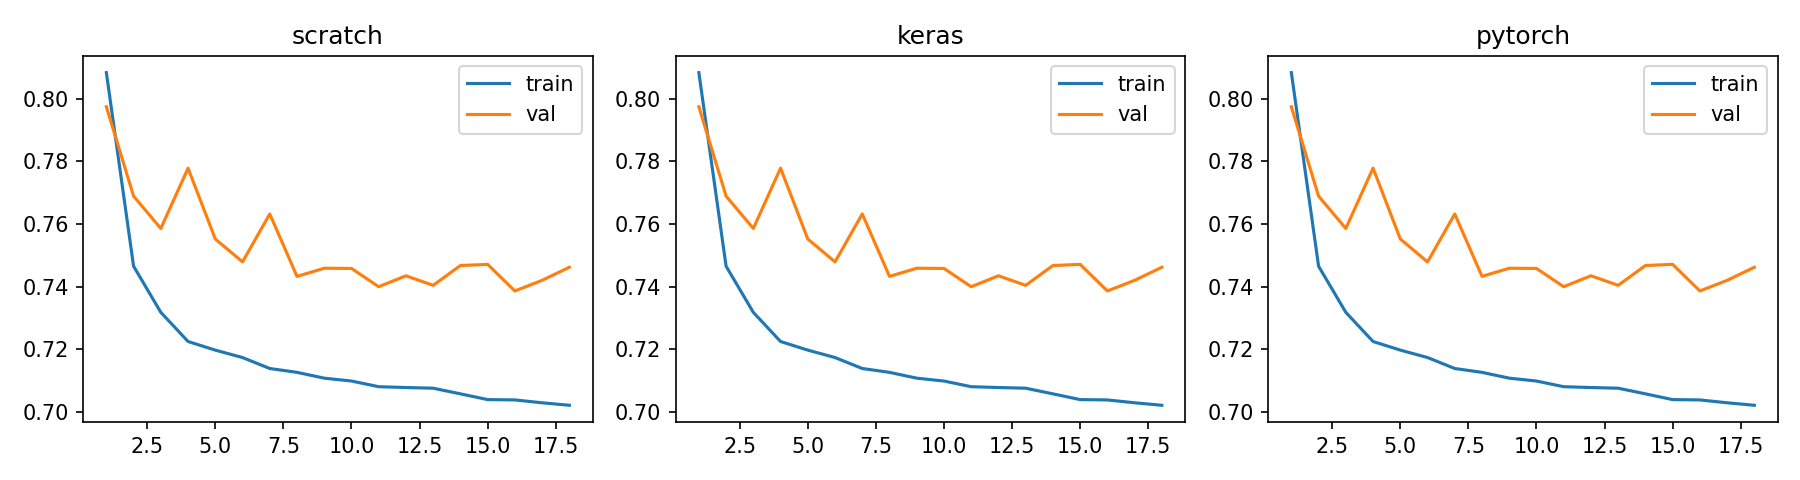

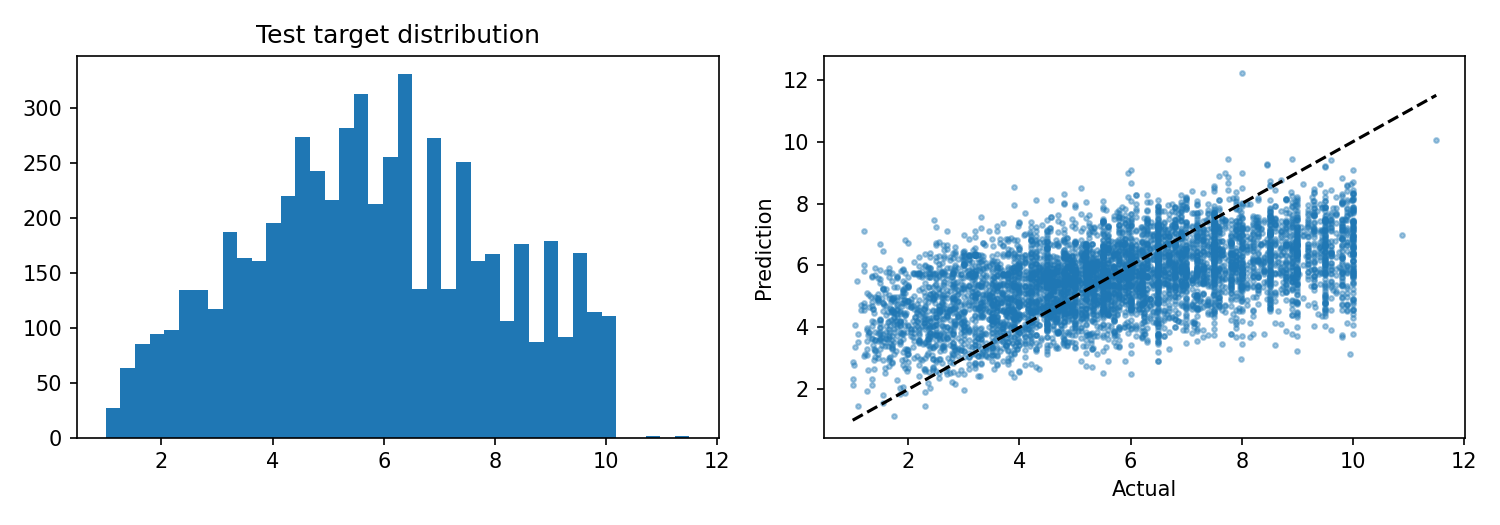

Baseline: {
  "RMSE": 2.2137915855391856,
  "MAE": 1.8355779647827148,
  "R2": -0.0027953386306762695
}
Chọn validation: {"framework": "keras", "criterion": "RMSE", "split": "validation"}


,index,actual,prediction,absolute_error
0,729,9.95,3.128695,6.821305
1,6824,10.00,3.789886,6.210114
2,16227,9.80,3.704366,6.095634
3,6188,9.80,3.761369,6.038631
4,20425,10.00,4.092423,5.907577
5,9578,1.20,7.105869,5.905869
6,15534,9.90,4.131684,5.768315
7,20718,9.00,3.241404,5.758596


In [16]:
display(summarize('housing').round(5))
for file in ['learning.png','evaluation.png','samples.png']:
    path=ROOT/'results/housing'/file
    if path.exists():display(Image(filename=str(path)))
print('Baseline:',(ROOT/'results/housing/baseline.json').read_text())
print('Chọn validation:',(ROOT/'results/housing/selection.json').read_text())
display(pd.read_json(ROOT/'results/housing/errors.json'))

## 5. Tiểu kết
Mỗi dataset có ba implementation được train độc lập. Kết quả chỉ áp dụng cho cấu hình nhỏ và seed42, chưa có đánh giá nhiều seed. Báo cáo nêu baseline và failure cases; không chọn model bằng test. Kiểm tra gradient bằng tools/check_gradients.py và checkpoint bằng tools/verify.py.

## Bổ sung so sánh mô hình khác nhau
Xem [notebook 06](06_architecture_comparison.ipynb): ba họ mô hình ML và bốn kiến trúc CNN/RNN trên các dataset hiện tại. Phần ở notebook này đối chiếu ba cách cài đặt của kiến trúc cơ sở; không coi ba thư viện là ba thuật toán khác nhau.